<a href="https://colab.research.google.com/github/Fares-pr0g/ML-journey-ep-2-Experimenting-with-NN-s-in-PyTorch/blob/main/Learning_PyTorch_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Custom Datasets

In [ ]:
import torch
from torch import nn
import torchvision

In [ ]:
device= "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
import requests
import zipfile
from pathlib import Path

# Let's setup the path to data folder
data_path= Path("data/")
image_path= data_path / "pizza_steak_sushi"

# Does the folder exist? If not, download it
if image_path.is_dir():
  print(f"{image_path} directory exists.")
else:
  print(f"Did not find {image_path} directory, creating one...")
  image_path.mkdir(parents= True, exist_ok= True)

  # Download pizza, steak, sushi data
  with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    print("Downloading pizza, steak, sushi data...")
    f.write(request.content)

  # Unzip pizza, steak, sushi data
  with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
    print("Unzipping pizza, steak, sushi data...")
    zip_ref.extractall(image_path)



Did not find data/pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


In [ ]:
#LLet's see what does the directory we just uploaded look like
import os
def walk_through_dir(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are { len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.


In [ ]:
# setup training & testing paths
train = image_path / "train"
test = image_path / "test"

train, test

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [ ]:
print(f"We have total of {len(list(image_path.glob("*/*/*.jpg")))} images as data points")

We have total of 300 images as data points


Random image path: data/pizza_steak_sushi/train/sushi/3004029.jpg
Random image shape: (512, 512)
Random image class: sushi


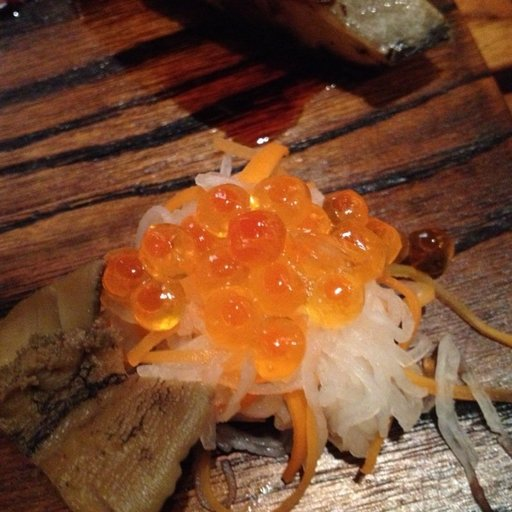

In [ ]:
import random
from PIL import Image

random.seed(42)
image_path_list = list(image_path.glob('*/*/*.jpg'))
random_img= random.choice(image_path_list)
img_class=  random_img.parent.stem
img =Image.open(random_img)

# print image metadata
print(f"Random image path: {random_img}")
print(f"Random image shape: {(img.height, img.width)}")
print(f"Random image class: {img_class}")

img

## Let's transform the data and get it ready for training

In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [ ]:
data_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

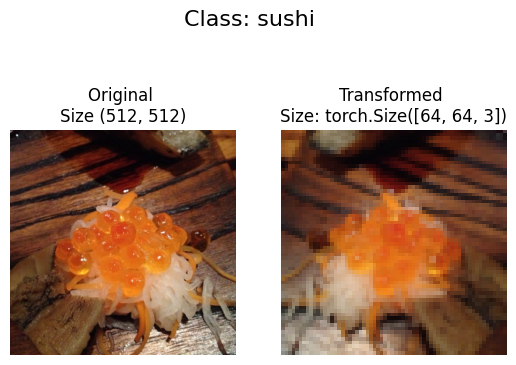

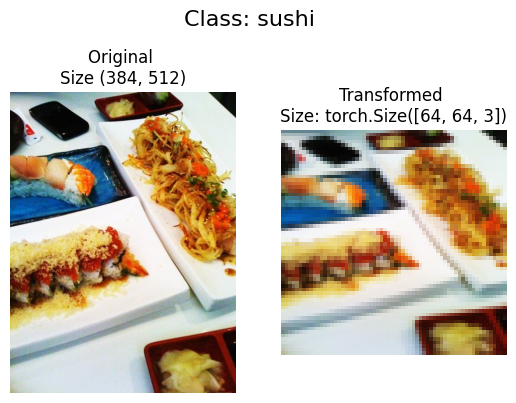

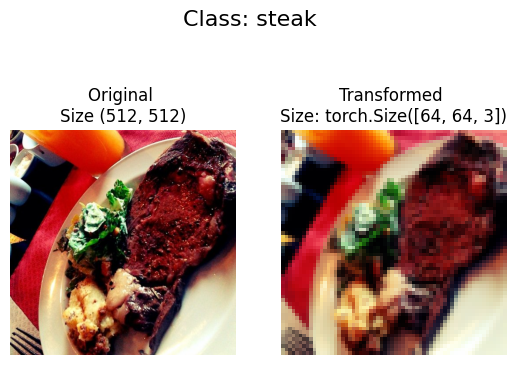

In [ ]:
def plot_transformed_images(image_path_list, transform, n=3, seed=42):

  random.seed(seed)
  random_image_paths= random.sample(image_path_list, k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(1,2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original \nSize {f.size}")
      ax[0].axis("off")

      # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
      transformed_image= transform(f).permute(1,2,0)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
      ax[1].axis("off")

      fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_path_list, data_transform)


## Let's load the data

In [ ]:
# Using ImageFolder since the dataset is in standard image classification format
train_data= datasets.ImageFolder(root= train,
                                 transform= data_transform,
                                 target_transform= None)

test_data= datasets.ImageFolder(root= test,
                                transform= data_transform)
print(f"Train data:\n {train_data}\nTest data:\n {test_data}")

Train data:
 Dataset ImageFolder
    Number of datapoints: 225
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
Test data:
 Dataset ImageFolder
    Number of datapoints: 75
    Root location: data/pizza_steak_sushi/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [ ]:
class_names= train_data.classes
class_dict= train_data.class_to_idx
class_names, class_dict


(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

**Note: following up on the resize from 512x512 to 64x64:**
if you think the image is harder to recognize what's going on, chances are a model will find it harder to understand too.

In [ ]:
from torch.utils.data import DataLoader
train_dataloader= DataLoader(dataset= train_data,
                             batch_size=1,
                             num_workers= os.cpu_count(),
                             shuffle= True)
test_dataloader= DataLoader(dataset= test_data,
                            batch_size=1,
                            num_workers= os.cpu_count(),
                            shuffle= False)

# What if we create a custom dataset

In [ ]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [ ]:
# Helper function: make a function to find classes in target directory
def find_classes(directory: str) -> Tuple[List[str], Dict[str,int]]:

  classes= sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
  if not classes:
    raise FileNotFoundError(f"Couldn't find any classes in {directory}.")

  class_to_idx= {cls_name: i for i, cls_name in enumerate(classes)}
  return classes, class_to_idx

In [ ]:
find_classes(train)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### Let's build torchvision.datasets.ImageFolder from scratch

In [ ]:
list(train.glob('*/*.jpg'))[0].parent.name

'sushi'

In [ ]:
# Write a custom dataset class (inherits from torch.utils.data.Dataset)
from torch.utils.data import Dataset

class ImageFolderCustom(Dataset):

  def __init__(self, targ_dir: str, transform= None):
    self.parent_dir= targ_dir
    self.paths= list(pathlib.Path(targ_dir).glob('*/*.jpg')) # this is adapted to our data format (.jpg)
    self.transform= transform
    self.classes, self.class_to_idx= find_classes(targ_dir)

  def load_image(self, idx: int) -> Image.Image:
    "Opens an image via a path and returns it"
    return Image.open(self.paths[idx])

  def __len__(self):
    "Returns the total number of samples"
    return len(self.paths)

  def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
    "Returns one sample of data, data and label (X, y)"
    img= self.load_image(idx)
    class_label= self.paths[idx].parent.stem
    class_idx= self.class_to_idx[class_label]

    if self.transform:
      return self.transform(img), class_idx
    else:
      return img, class_idx


**Note:** Historically, torchvision.transforms worked primarily with PIL Image objects.

In [ ]:
# Set the transformer
# noting: the data augmentation applies only for training data

train_transforms= transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transforms= transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

In [ ]:
# Let's turn our data from the folders to data objects
train_data_custom= ImageFolderCustom(train, transform= train_transforms)
test_data_custom= ImageFolderCustom(test, transform= test_transforms)

train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x7d3ce4645550>,
 <__main__.ImageFolderCustom at 0x7d3cf415fc50>)

In [ ]:
# Let's run some methods and see if everythin's fine

print(len(train_data_custom), len(test_data_custom))
print(train_data_custom.classes, train_data_custom.class_to_idx)


225 75
['pizza', 'steak', 'sushi'] {'pizza': 0, 'steak': 1, 'sushi': 2}


In [ ]:
def display_random_images(dataset, classes: List[str]=None,
                          display_shape=True, n=10, seed=None):
  # n shouldn't be higher than 10 for display purposes
  if n> 10:
    n=10
    display_shape=False
    print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")

  if seed:
    random.seed(seed)

  random_samples_idx= random.sample(range(len(dataset)), k=n)

  plt.figure(figsize=(16,8))
  for i, rand_idx in enumerate(random_samples_idx):
    targ_img, targ_label= dataset[rand_idx]

    plt.subplot(1,n,i+1)
    plt.imshow(targ_img.permute(1,2,0))
    plt.axis("off")
    if classes:
      title= f"class: {classes[targ_label]}"
      if display_shape:
        title+= f"\nshape: {targ_img.permute(1,2,0).shape}"
    plt.title(title)





For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.


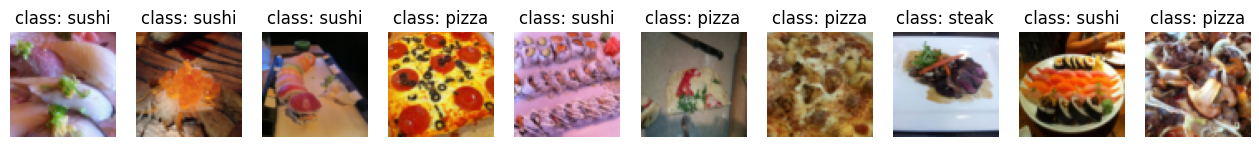

In [ ]:
display_random_images(train_data_custom, classes= train_data_custom.classes, n=15)

**Note:** Since our custom dataset is inheriting fom Dataset class -> we can use a DataLoader

## A deeper dive in data augmentation

**Note:** **Data augmentation** is the process of altering your data in such a way that you artificially increase the diversity of your training set. -> Better generalization

In [ ]:
from torchvision import transforms

aug_train_transforms= transforms.Compose([
    transforms.Resize((224,224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

aug_test_transforms= transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

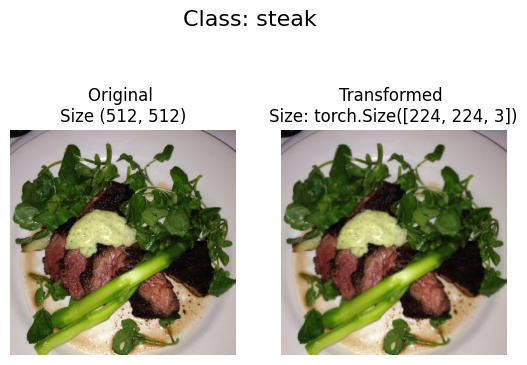

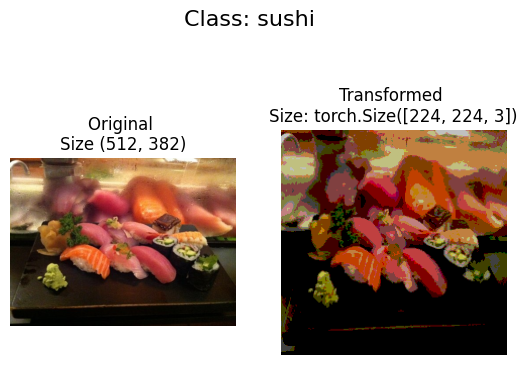

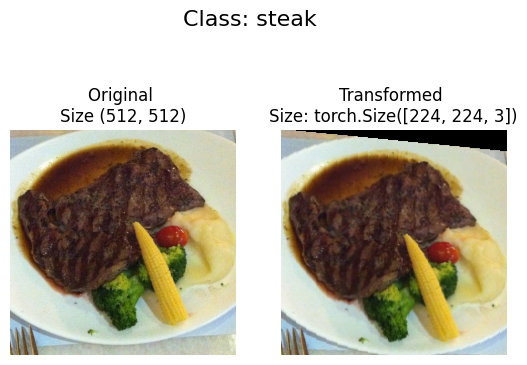

In [ ]:
# Let's test our data augmentation out!
plot_transformed_images(image_path_list, aug_train_transforms, n=3, seed=None)

# Let's start training!

## First, without data augmentation

In [ ]:
# Simple transform: No data augmentation
simple_transform= transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

In [ ]:
# functionize data preprocessing
def data_preprocessing(parent_dir: Path, train_transform: transforms.Compose, test_transform: transforms.Compose):
  train_dir= parent_dir / "train"
  test_dir= parent_dir / "test"

  from torchvision import datasets
  train_data= datasets.ImageFolder(root=train_dir,
                                          transform=train_transform)
  test_data= datasets.ImageFolder(root=test_dir,
                                         transform=test_transform)
  import os
  from torch.utils.data import DataLoader

  BATCH_SIZE= 32
  NUM_WORKERS= os.cpu_count()
  print( f"Creating DataLoader with batch size {BATCH_SIZE} and {NUM_WORKERS} workers")

  train_dataloader= DataLoader(train_data, batch_size= BATCH_SIZE,
                               shuffle=True,
                               num_workers= NUM_WORKERS)
  test_dataloader= DataLoader(test_data, batch_size= BATCH_SIZE,
                               shuffle=False,
                               num_workers= NUM_WORKERS)
  return train_dataloader, test_dataloader, train_data, test_data

# CASE 0: Simple Use

train_dataloader_simple, test_dataloader_simple, train_data, test_data= data_preprocessing(image_path, simple_transform,simple_transform)


Creating DataLoader with batch size 32 and 2 workers


In [ ]:
# TinyVGG model class

class TinyVGG(nn.Module):

  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()
    self.conv_block_1= nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2) #default stride value is same as kernel_size
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.classifier= nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features= hidden_units*16*16,
                  out_features= output_shape)
    )
  def forward(self, X: torch.Tensor):
    X= self.conv_block_1(X)
    X= self.conv_block_2(X)
    X= self.classifier(X)
    return X

torch.manual_seed(42)
model_0= TinyVGG(input_shape=3, hidden_units=10,
                 output_shape= len(train_data.classes)).to(device)

model_0


TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [ ]:
# Let's get an idea on the shapes going through our model with torchinfo
!pip install torchinfo
import torchinfo

from torchinfo import summary
summary(model_0, input_size=[32,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [32, 3]                   --
├─Sequential: 1-1                        [32, 10, 32, 32]          --
│    └─Conv2d: 2-1                       [32, 10, 64, 64]          280
│    └─ReLU: 2-2                         [32, 10, 64, 64]          --
│    └─Conv2d: 2-3                       [32, 10, 64, 64]          910
│    └─ReLU: 2-4                         [32, 10, 64, 64]          --
│    └─MaxPool2d: 2-5                    [32, 10, 32, 32]          --
├─Sequential: 1-2                        [32, 10, 16, 16]          --
│    └─Conv2d: 2-6                       [32, 10, 32, 32]          910
│    └─ReLU: 2-7                         [32, 10, 32, 32]          --
│    └─Conv2d: 2-8                       [32, 10, 32, 32]          910
│    └─ReLU: 2-9                         [32, 10, 32, 32]          --
│    └─MaxPool2d: 2-10                   [32, 10, 16, 16]          --
├─Sequentia

In [ ]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer):
  model.train()
  train_loss, train_acc= 0,0
  for batch, (X,y) in enumerate(dataloader):
    X,y = X.to(device), y.to(device)
    optimizer.zero_grad()

    y_pred= model(X)
    loss= loss_fn(y_pred, y)
    train_loss+= loss.item()

    loss.backward()
    optimizer.step()

    y_pred_class= torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    train_acc+= (y_pred_class == y).sum().item()/len(y_pred)

  # Calculate and accumulate accuracy metrics across all batches
  train_loss= train_loss / len(dataloader)
  train_acc= train_acc / len(dataloader)
  return train_loss, train_acc*100


In [ ]:
def test_step(model: torch.nn.Module,
              dataloader:torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
  model.eval()
  test_loss, test_acc= 0,0
  with torch.inference_mode():
    for batch, (X,y) in enumerate(dataloader):
      X,y = X.to(device), y.to(device)
      test_pred_logits= model(X)
      loss= loss_fn(test_pred_logits,y)
      test_loss+=loss.item()

      test_pred_labels= torch.argmax(test_pred_logits, dim=1)
      test_acc+=(test_pred_labels == y).sum().item()/ len(y)

  test_loss /= len(dataloader)
  test_acc /= len(dataloader)

  return test_loss, test_acc*100


In [ ]:
from tqdm.auto import tqdm

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer:torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int =5):

  # 2. Create empty results dictionary
  results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
  }
  for epoch in range(epochs):
    train_loss, train_acc= train_step(model=model,
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer)
    test_loss, test_acc= test_step(model=model,
                                   dataloader= test_dataloader,
                                   loss_fn=loss_fn)
    if (epochs < 20) or (epoch %10== 0):
      print(
              f"{epochs//10}"
              f"Epoch: {epoch+1} | "
              f"train_loss: {train_loss:.4f} | "
              f"train_acc: {train_acc:.4f} | "
              f"test_loss: {test_loss:.4f} | "
              f"test_acc: {test_acc:.4f}"
          )


    # Ensure all data is moved to CPU and converted to float for storage
    results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
    results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
    results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
    results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)
  return results



In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS= 100

#Setup loss funct. and optimizer
loss_fn= nn.CrossEntropyLoss()
optimizer= torch.optim.Adam(params=model_0.parameters(), lr=0.001)

from timeit import default_timer as timer
start_time= timer()

model_0_results= train(model=model_0,
                       train_dataloader=train_dataloader_simple,
                       test_dataloader=test_dataloader_simple,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs= NUM_EPOCHS)

end_time= timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

10Epoch: 1 | train_loss: 1.1071 | train_acc: 25.0000 | test_loss: 1.1061 | test_acc: 26.0417
10Epoch: 11 | train_loss: 0.9492 | train_acc: 62.5000 | test_loss: 1.0535 | test_acc: 34.2803
10Epoch: 21 | train_loss: 0.7122 | train_acc: 72.2656 | test_loss: 1.0442 | test_acc: 47.5379
10Epoch: 31 | train_loss: 0.5099 | train_acc: 81.6406 | test_loss: 1.0111 | test_acc: 44.4129
10Epoch: 41 | train_loss: 0.4661 | train_acc: 85.1562 | test_loss: 1.1529 | test_acc: 48.5795
10Epoch: 51 | train_loss: 0.2189 | train_acc: 94.5312 | test_loss: 1.6413 | test_acc: 45.5492
10Epoch: 61 | train_loss: 0.0897 | train_acc: 98.8281 | test_loss: 2.1092 | test_acc: 43.4659
10Epoch: 71 | train_loss: 0.2261 | train_acc: 90.2344 | test_loss: 2.3920 | test_acc: 39.2045
10Epoch: 81 | train_loss: 0.0366 | train_acc: 99.6094 | test_loss: 2.8672 | test_acc: 39.2992
10Epoch: 91 | train_loss: 0.0113 | train_acc: 100.0000 | test_loss: 3.2278 | test_acc: 39.2992
Total training time: 108.054 seconds


##  Holy overfit!!

In [ ]:
def plot_loss_curves(results: Dict[str, List[float]]):
  loss= results['train_loss']
  test_loss= results['test_loss']

  acc= results["train_acc"]
  test_acc= results["test_acc"]

  epochs= range(len(results["train_loss"]))

  plt.figure(figsize=(15,7))

  plt.subplot(1, 2, 1)
  plt.plot(epochs, loss, label='train_loss')
  plt.plot(epochs, test_loss, label='test_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(epochs, acc, label='train_accuracy')
  plt.plot(epochs, test_acc, label='test_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

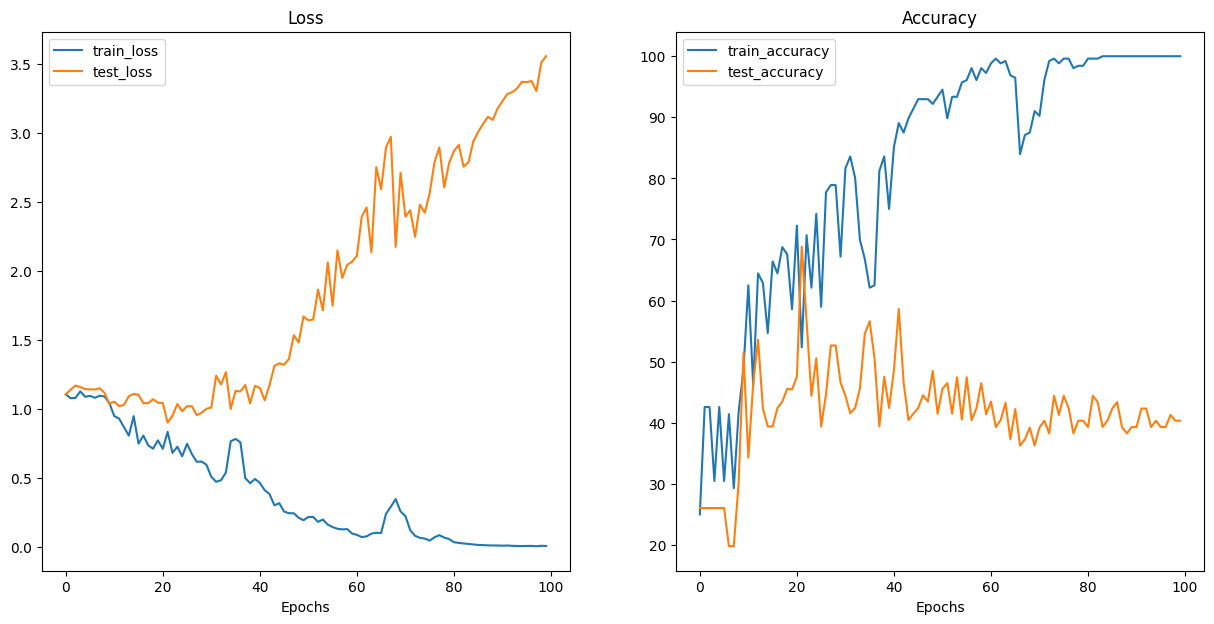

In [ ]:
plot_loss_curves(model_0_results)

The model is clearly overfitting! We need to do smth abt it

# Model 1: TinyVGG with Data Augmentation

In [ ]:
# Now we add the TrivialAugment to the training transform
transform_trivial_augment= transforms.Compose([
    transforms.Resize((64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

In [ ]:
train_dataloader_aug, test_dataloader_aug, train_data_aug, test_data_aug= data_preprocessing(image_path,
                                                                                           train_transform= transform_trivial_augment,
                                                                                           test_transform=simple_transform)

Creating DataLoader with batch size 32 and 2 workers


In [ ]:
torch.manual_seed(42)
model_1= TinyVGG(
    input_shape=3,
    hidden_units=10,
    output_shape=len(train_data_aug.classes)
).to(device)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS= 100

#Setup loss funct. and optimizer
loss_fn= nn.CrossEntropyLoss()
optimizer= torch.optim.Adam(params=model_1.parameters(), lr=0.001)

from timeit import default_timer as timer
start_time= timer()

model_1_results= train(model=model_1,
                       train_dataloader=train_dataloader_aug,
                       test_dataloader=test_dataloader_aug,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs= NUM_EPOCHS)

end_time= timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

10Epoch: 1 | train_loss: 1.1076 | train_acc: 25.0000 | test_loss: 1.1062 | test_acc: 26.0417
10Epoch: 11 | train_loss: 1.0917 | train_acc: 43.3594 | test_loss: 1.1092 | test_acc: 26.0417
10Epoch: 21 | train_loss: 0.9436 | train_acc: 60.1562 | test_loss: 1.0116 | test_acc: 42.3295
10Epoch: 31 | train_loss: 0.8723 | train_acc: 60.9375 | test_loss: 0.9678 | test_acc: 49.4318
10Epoch: 41 | train_loss: 0.9780 | train_acc: 48.8281 | test_loss: 1.0040 | test_acc: 45.5492
10Epoch: 51 | train_loss: 0.8961 | train_acc: 59.3750 | test_loss: 1.0629 | test_acc: 38.3523
10Epoch: 61 | train_loss: 0.9906 | train_acc: 51.1719 | test_loss: 1.0005 | test_acc: 41.3826
10Epoch: 71 | train_loss: 0.8172 | train_acc: 65.2344 | test_loss: 0.9596 | test_acc: 44.5076
10Epoch: 81 | train_loss: 0.8229 | train_acc: 63.6719 | test_loss: 0.9782 | test_acc: 45.3598
10Epoch: 91 | train_loss: 0.8356 | train_acc: 66.0156 | test_loss: 1.0459 | test_acc: 43.4659
Total training time: 116.025 seconds


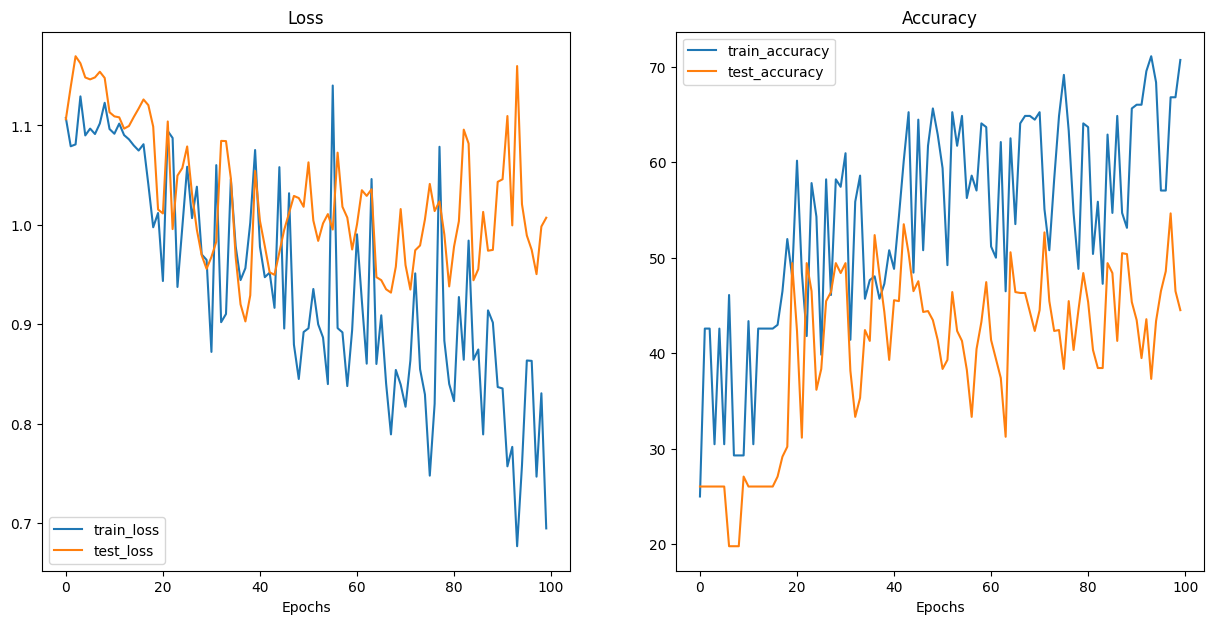

In [ ]:
plot_loss_curves(model_1_results)

### What about we test a custom image on the model

In [ ]:
def pred_and_plot_img(model: torch.nn.Module,
                      image_path,
                      class_names: List[str]=None,
                      transform= None,
                      device: torch.device = device):

  # Open image with PIL to be compatible with torchvision transforms
  target_img_pil = Image.open(image_path)

  if transform:
    target_img= transform(target_img_pil)
  else:
    # If no transform is provided, convert PIL Image to Tensor and normalize
    target_img = transforms.ToTensor()(target_img_pil)
    if target_img.max().item() > 1:
        target_img /= 255

  model.to(device)
  model.eval()
  with torch.inference_mode():
    target_img_unsqueezed = target_img.unsqueeze(dim=0)
    pred= model(target_img_unsqueezed.to(device))

  probs= torch.softmax(pred, dim=1)
  label= torch.argmax(probs, dim=1)


  plt.imshow(target_img.squeeze().permute(1, 2, 0)) # make sure it's the right size for matplotlib

  if class_names:
    title = f"Pred: {class_names[label.cpu()]} | Prob: {probs.max().cpu():.3f}"
  else:
    title = f"Pred: {label} | Prob: {probs.max().cpu():.3f}"
  plt.title(title)
  plt.axis(False);

In [ ]:
from google.colab import files

uploaded= files.upload()

(np.float64(-0.5), np.float64(1279.5), np.float64(959.5), np.float64(-0.5))

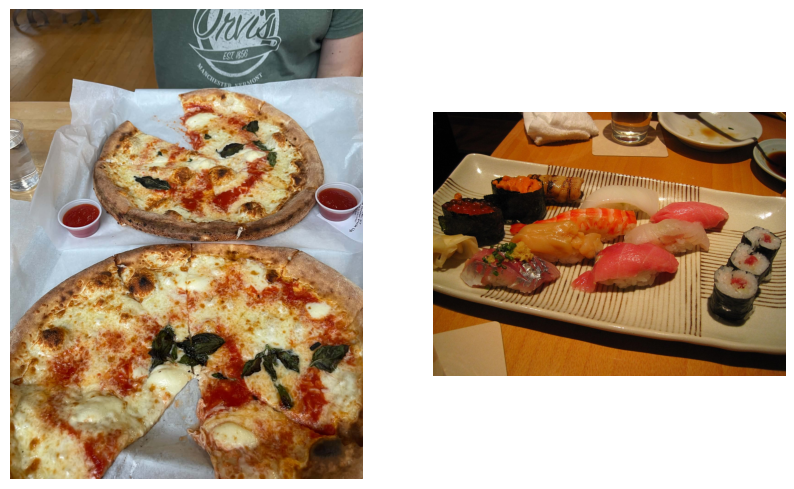

In [ ]:
custom_img_1= Path("/content/custom pizza pic.jpg")
custom_img_2= Path("/content/custom sushi pic.jpg")

fig, ax= plt.subplots(1,2, figsize=(10,10))
img_1= Image.open(custom_img_1)
img_2= Image.open(custom_img_2)
ax[0].imshow(img_1)
ax[1].imshow(img_2)
ax[0].axis("off")
ax[1].axis("off")

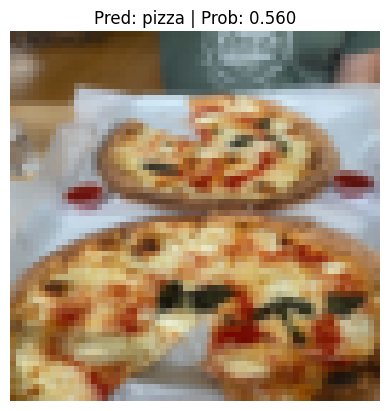

In [ ]:
pred_and_plot_img(model=model_1,
                  image_path=custom_img_1,
                  class_names=train_data_aug.classes,
                  transform= simple_transform,
                  device=device)

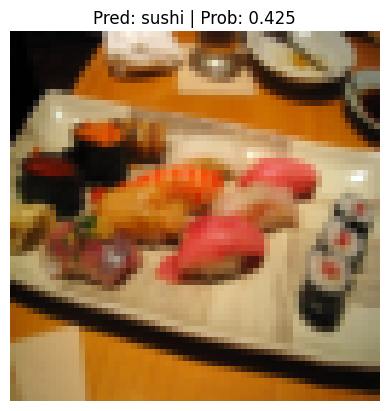

In [ ]:
pred_and_plot_img(model=model_1,
                  image_path=custom_img_2,
                  class_names=train_data_aug.classes,
                  transform= transform_trivial_augment,
                  device=device)

# Model 2: Experimenting with a deeper CNN

In [ ]:

class Custom_CNN(nn.Module):

  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()
    self.conv_block_1= nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2) #default stride value is same as kernel_size
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.conv_block_3 = nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.classifier= nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features= hidden_units*16*16,
                  out_features= output_shape)
    )
  def forward(self, X: torch.Tensor):
    X= self.conv_block_1(X)
    X= self.conv_block_2(X)
    X= self.conv_block_3(X)
    X= self.classifier(X)
    return X

torch.manual_seed(42)
model_2= Custom_CNN(input_shape=3, hidden_units=10,
                 output_shape= len(train_data.classes)).to(device)

model_2

Custom_CNN(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_3): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_

### Let's upscale the images size as well

In [ ]:

transform_upscale_augment= transforms.Compose([
    transforms.Resize((128,128)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

transform_upscale_simple= transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

In [ ]:
train_dataloader_up, test_dataloader_up, train_data_up, test_data_up= data_preprocessing(image_path,
                                                                                           train_transform= transform_upscale_augment,
                                                                                           test_transform=transform_upscale_simple)


Creating DataLoader with batch size 32 and 2 workers


In [ ]:

torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS= 100

#Setup loss funct. and optimizer
loss_fn= nn.CrossEntropyLoss()
optimizer= torch.optim.Adam(params=model_2.parameters(), lr=0.001)

from timeit import default_timer as timer
start_time= timer()

model_2_results= train(model=model_2,
                       train_dataloader=train_dataloader_up,
                       test_dataloader=test_dataloader_up,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs= NUM_EPOCHS)

end_time= timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

10Epoch: 1 | train_loss: 1.1073 | train_acc: 25.0000 | test_loss: 1.0984 | test_acc: 26.0417
10Epoch: 11 | train_loss: 1.0968 | train_acc: 42.5781 | test_loss: 1.1028 | test_acc: 26.0417
10Epoch: 21 | train_loss: 0.9352 | train_acc: 60.9375 | test_loss: 1.0563 | test_acc: 37.3106
10Epoch: 31 | train_loss: 0.8278 | train_acc: 64.8438 | test_loss: 0.9886 | test_acc: 50.4735
10Epoch: 41 | train_loss: 0.9837 | train_acc: 45.3125 | test_loss: 1.0119 | test_acc: 40.4356
10Epoch: 51 | train_loss: 0.8578 | train_acc: 60.1562 | test_loss: 1.0743 | test_acc: 37.3106
10Epoch: 61 | train_loss: 1.0171 | train_acc: 53.5156 | test_loss: 1.0431 | test_acc: 40.3409
10Epoch: 71 | train_loss: 0.7455 | train_acc: 69.5312 | test_loss: 0.9739 | test_acc: 54.5455
10Epoch: 81 | train_loss: 0.9321 | train_acc: 52.7344 | test_loss: 0.9858 | test_acc: 46.4962
10Epoch: 91 | train_loss: 0.8073 | train_acc: 64.8438 | test_loss: 1.2668 | test_acc: 37.4053
Total training time: 128.684 seconds


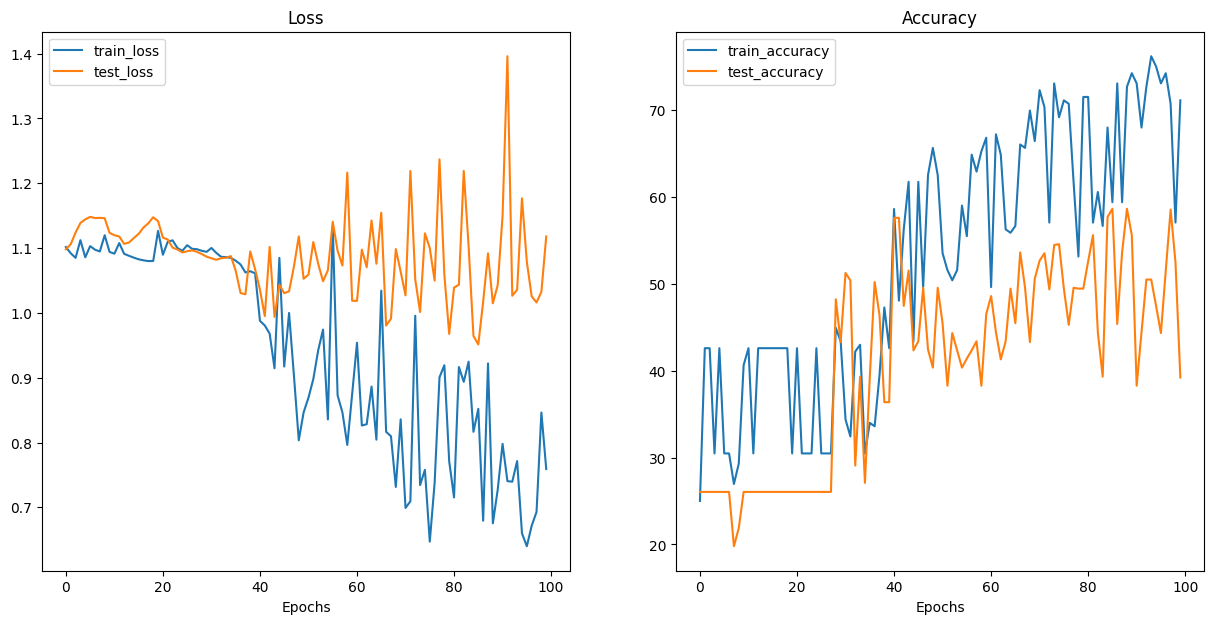

In [ ]:
plot_loss_curves(model_2_results)